# 📊 Customer Segmentation Analysis using K-Means Clustering

## Oasis Infobyte Internship – Data Analytics (Level 1)

### Objective

The objective of this project is to segment customers into different groups based on their annual income and spending score using the K-Means Clustering algorithm.

Customer segmentation helps businesses understand customer behavior and create targeted marketing strategies.

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

%matplotlib inline

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(8,5)

# Loading the Dataset

The Mall Customers dataset is loaded using the Pandas library.

In [2]:
df = pd.read_csv("Mall_Customers.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


# Display First Five Records

This helps us understand the dataset structure.

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Dataset Information

Checking the number of records, columns, data types and missing values.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


# Dataset Shape

Finding the total number of rows and columns.

In [5]:
print("Dataset Shape :", df.shape)

Dataset Shape : (200, 5)


# Missing Value Analysis

Checking whether the dataset contains any missing values.

In [6]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

# Duplicate Records

Checking duplicate rows in the dataset.

In [7]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


# Descriptive Statistics

Statistical summary of the dataset.

In [8]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Observation

- The dataset contains customer demographic and spending information.
- No missing values are present.
- The dataset is clean and suitable for clustering.

# Gender Distribution

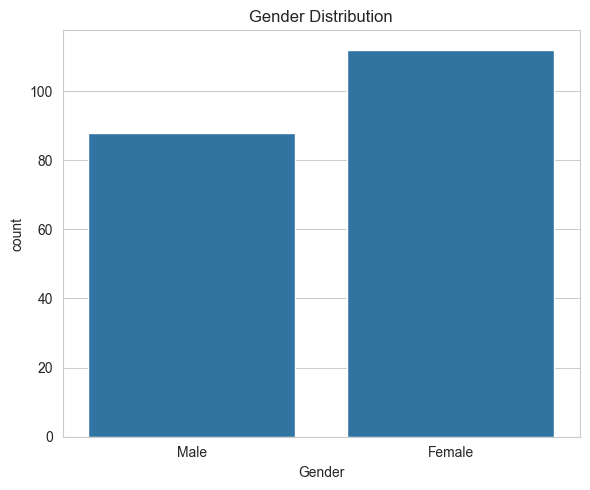

In [9]:
plt.figure(figsize=(6,5))

sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")

plt.tight_layout()

plt.savefig("images/gender_distribution.png", dpi=300)

plt.show()

### Observation

- The dataset contains both male and female customers.
- Female customers are slightly higher in number.

# Age Distribution

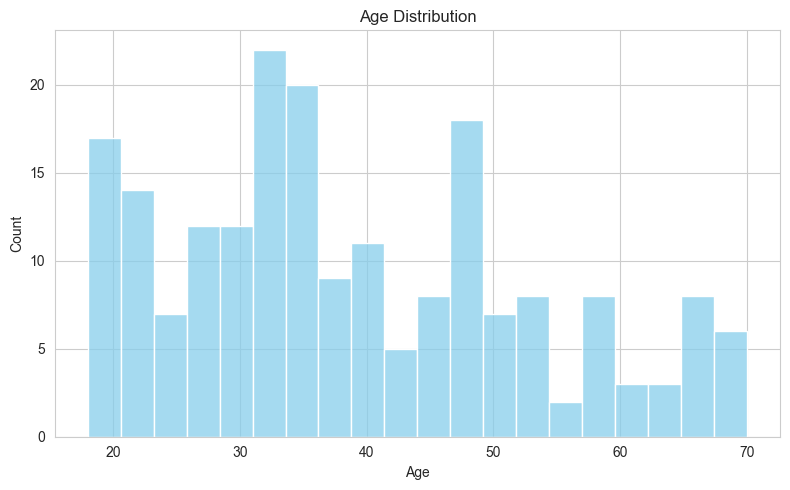

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, color="skyblue")

plt.title("Age Distribution")

plt.tight_layout()

plt.savefig("images/age_distribution.png", dpi=300)

plt.show()

### Observation

- Most customers belong to the age group of 20–40 years.
- Younger customers dominate the dataset.

# Annual Income Distribution

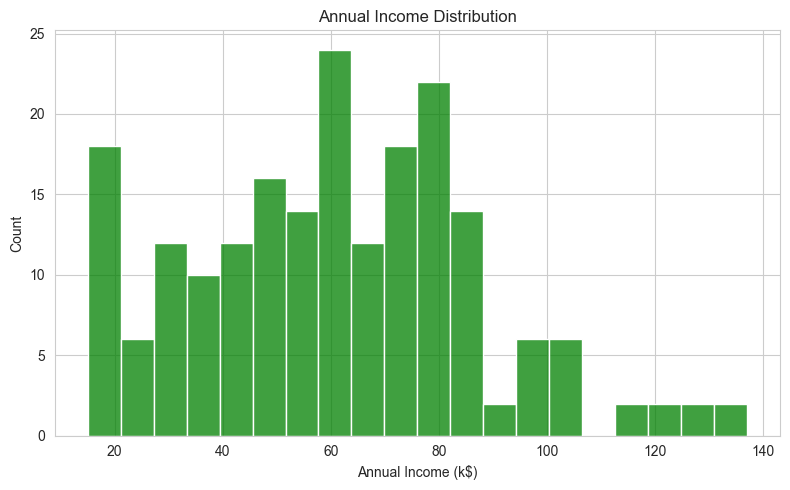

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["Annual Income (k$)"], bins=20, color="green")

plt.title("Annual Income Distribution")

plt.tight_layout()

plt.savefig("images/income_distribution.png", dpi=300)

plt.show()

### Observation

- Most customers have a medium annual income.

# Spending Score Distribution

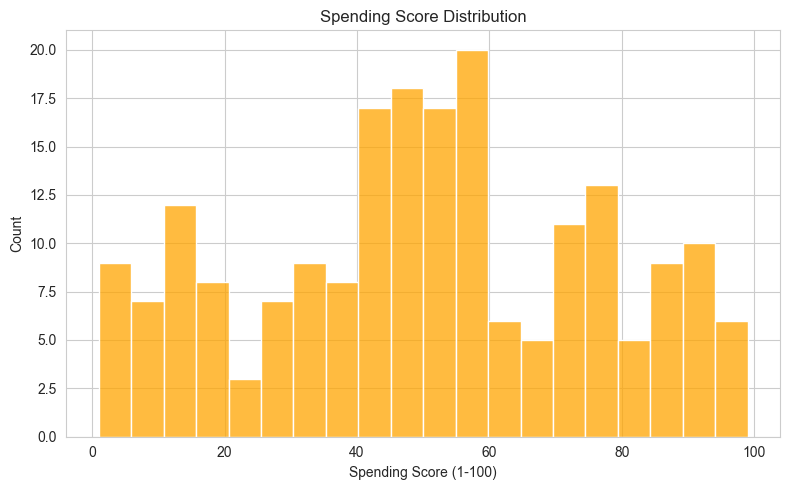

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["Spending Score (1-100)"], bins=20, color="orange")

plt.title("Spending Score Distribution")

plt.tight_layout()

plt.savefig("images/spending_distribution.png", dpi=300)

plt.show()

### Observation

- Customers exhibit varying spending habits.
- Spending scores range from low to high.

# Selecting Features for Clustering

Annual Income and Spending Score are selected because they best represent customer purchasing behavior.

In [13]:
X = df.iloc[:, [3,4]].values

# Elbow Method

The Elbow Method is used to determine the optimal number of clusters.

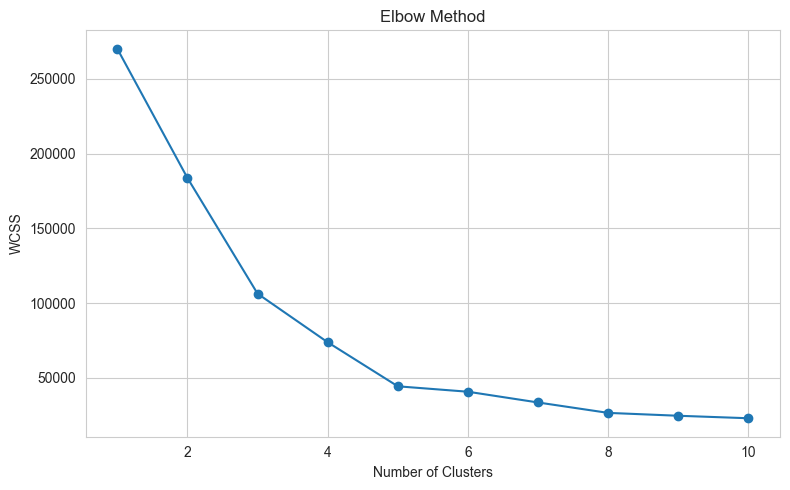

In [14]:
wcss=[]

for i in range(1,11):

    kmeans=KMeans(n_clusters=i,init="k-means++",random_state=42)

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker="o")

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.tight_layout()

plt.savefig("images/elbow_method.png",dpi=300)

plt.show()

### Observation

The elbow point appears around **5 clusters**, indicating that five customer groups are optimal.

# Applying K-Means Clustering

In [15]:
kmeans=KMeans(n_clusters=5,init="k-means++",random_state=42)

y_pred=kmeans.fit_predict(X)

# Customer Segments Visualization

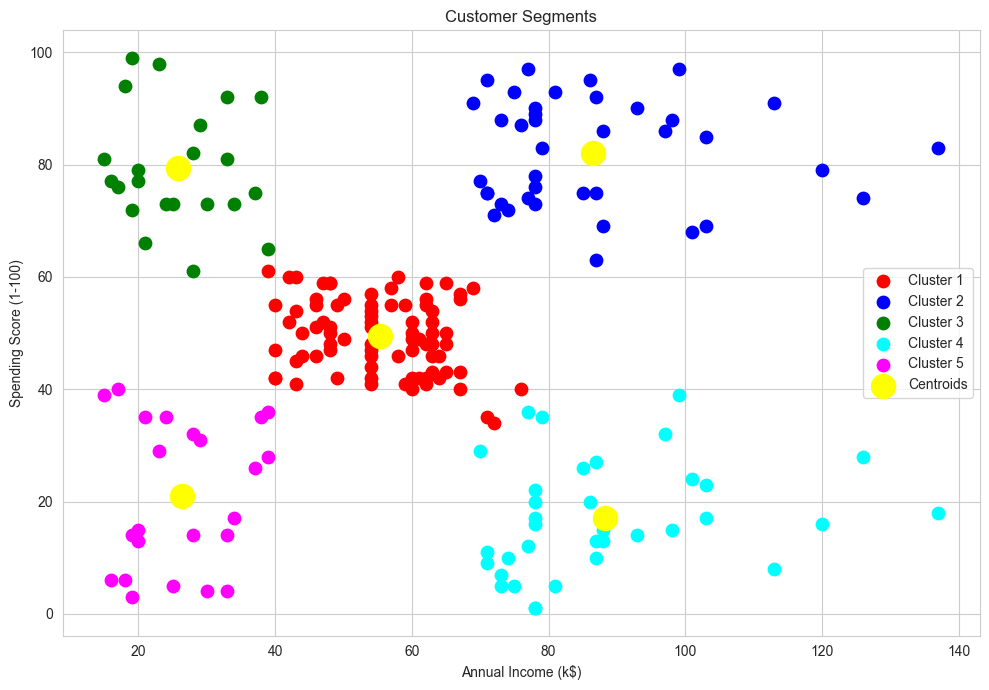

In [16]:
plt.figure(figsize=(10,7))

colors=["red","blue","green","cyan","magenta"]

for i in range(5):

    plt.scatter(
        X[y_pred==i,0],
        X[y_pred==i,1],
        s=80,
        c=colors[i],
        label=f"Cluster {i+1}"
    )

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c="yellow",
    label="Centroids"
)

plt.title("Customer Segments")

plt.xlabel("Annual Income (k$)")

plt.ylabel("Spending Score (1-100)")

plt.legend()

plt.tight_layout()

plt.savefig("images/customer_segments.png",dpi=300)

plt.show()

# Business Insights

- High Income & High Spending customers are premium customers.
- High Income & Low Spending customers can be targeted through promotional campaigns.
- Low Income & High Spending customers are potential loyal customers.
- Low Income & Low Spending customers require cost-effective marketing.
- Medium Income customers represent the largest customer segment.

# Conclusion

Customer segmentation using K-Means Clustering successfully grouped customers into five meaningful segments.

These insights can help businesses design targeted marketing strategies, improve customer retention, and maximize profits.